<a href="https://colab.research.google.com/github/Mariagiusi23/ID-001-AWOL-for-Audio/blob/main/notebook/04_Latent_Space_Exploration_with_Conditional_Flow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 Notebook 4 — Latent-Space Exploration with Conditional Flow

This notebook showcases **latent-space exploration** using the models trained in
Notebook 03: a *conditional RealNVP* with learnable masks and a regressor
**g(c) → z**. We will:
- load the checkpoints (flow, g),
- run **seen** and **unseen** prompts (CLAP text embeddings),
- generate synthesizer parameters **ŷ(c) = flow⁻¹(g(c), c)**,
- plot trajectories from **interpolations** (in both conditioning `c` and latent `z`),
- render demo audio (simple FM synthesis), and
- expose a small **Gradio** demo.




# **🎯 STEP 1 — Setup**

**📍1.1 — Environment & basic config**

In [ ]:
!pip -q install transformers torchaudio soundfile gradio plotly scikit-learn --upgrade

import os, io, json, math, urllib.request
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

import plotly.express as px
from sklearn.decomposition import PCA
import soundfile as sf

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

OUTDIR = Path("nb04_outputs")
(OUTDIR / "tables").mkdir(parents=True, exist_ok=True)
(OUTDIR / "figs").mkdir(parents=True, exist_ok=True)
(OUTDIR / "wavs").mkdir(parents=True, exist_ok=True)

print("DEVICE:", DEVICE)

DEVICE: cpu


**📍1.2 — Artifacts on GitHub**

In [ ]:
RAW_BASE = "https://raw.githubusercontent.com/Mariagiusi23/ID-001-AWOL-for-Audio/main/assets/notebook_03/outputs_nb03"

FLOW_URL = f"{RAW_BASE}/realnvp_cond_mask.pt"
G_URL    = f"{RAW_BASE}/mlp_z.pt"


def _load_bytes_from_url(url):
    with urllib.request.urlopen(url, timeout=30) as r:
        return io.BytesIO(r.read())

def _torch_load_any(url=None, local=None):
    if local and os.path.exists(local):
        return torch.load(local, map_location=DEVICE)
    assert url is not None, "Provide either URL or local path."
    buf = _load_bytes_from_url(url)
    return torch.load(buf, map_location=DEVICE)

def _json_load_any(url=None, local=None):
    if local and os.path.exists(local):
        with open(local, "r", encoding="utf-8") as f: return json.load(f)
    if url is None: return None
    with urllib.request.urlopen(url, timeout=30) as r:
        return json.loads(r.read().decode("utf-8"))

# **🎯STEP 2 — Restore models & CLAP embeddings**

**📍2.1 — Conditional RealNVP + MLP_Z**

In [ ]:
def safe_sigmoid(x, eps=1e-6):
    return torch.clamp(torch.sigmoid(x), eps, 1. - eps)

class STBinary(torch.autograd.Function):
    @staticmethod
    def forward(ctx, p, thr: float):
        return (p > thr).float()
    @staticmethod
    def backward(ctx, g):
        return g, None

def binarize_st(p, thr=0.5):
    return STBinary.apply(p, thr)

class LearnableMask(nn.Module):
    def __init__(self, k: int, init_prob: float = 0.5):
        super().__init__()
        p0 = torch.full((k,), float(init_prob)).clamp(1e-3, 1-1e-3)
        logits = torch.log(p0) - torch.log(1 - p0)
        self.logits = nn.Parameter(logits)
    def forward(self, tau: float = 1.0, hard: bool = True):
        probs = safe_sigmoid(self.logits / tau)
        m = binarize_st(probs, 0.5) if hard else probs
        return m, probs
    def regularizer(self, target_frac=0.5):
        p = safe_sigmoid(self.logits)
        frac = p.mean()
        ent = - (p*torch.log(p+1e-8) + (1-p)*torch.log(1-p+1e-8)).mean()
        return (frac - target_frac).abs() + 0.1 * ent

class STNet(nn.Module):
    def __init__(self, in_dim: int, out_dim: int, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, 2*out_dim)
        )
    def forward(self, x):
        s, t = self.net(x).chunk(2, dim=-1)
        s = torch.tanh(s)
        return s, t

class AffineCoupling(nn.Module):
    def __init__(self, k: int, c_dim: int, hidden: int = 128):
        super().__init__()
        self.mask = LearnableMask(k)
        self.st = STNet(k + c_dim, k, hidden)
    def forward(self, y, c, tau: float = 1.0):
        m, _ = self.mask(tau=tau, hard=True)
        m = m[None, :]
        yA = y * m
        s, t = self.st(torch.cat([yA, c], dim=-1))
        B = 1.0 - m
        zB = (y * B) * torch.exp(s * B) + t * B
        z = yA + zB
        logdet = (s * B).sum(dim=-1)
        return z, logdet
    def inverse(self, z, c, tau: float = 1.0):
        m, _ = self.mask(tau=tau, hard=True)
        m = m[None, :]
        zA = z * m
        s, t = self.st(torch.cat([zA, c], dim=-1))
        B = 1.0 - m
        yB = (z * B - t * B) * torch.exp(-s * B)
        y = zA + yB
        return y
    def mask_reg(self, target_frac=0.5):
        return self.mask.regularizer(target_frac=target_frac)

class RealNVPCond(nn.Module):
    def __init__(self, k: int, c_dim: int, n_layers: int = 4, hidden: int = 128):
        super().__init__()
        self.layers = nn.ModuleList([AffineCoupling(k, c_dim, hidden) for _ in range(n_layers)])
        self.k = k; self.c_dim = c_dim
    def forward(self, y, c, tau: float = 1.0):
        x, logdet = y, 0.0
        for layer in self.layers:
            x, ld = layer(x, c, tau=tau)
            logdet = logdet + ld
        return x, logdet
    def inverse(self, z, c, tau: float = 1.0):
        x = z
        for layer in reversed(self.layers):
            x = layer.inverse(x, c, tau=tau)
        return x

class MLP_Z(nn.Module):
    def __init__(self, c_dim: int, k: int, hidden: int = 256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(c_dim, hidden), nn.GELU(),
            nn.Linear(hidden, hidden), nn.GELU(),
            nn.Linear(hidden, k),
        )
    def forward(self, c): return self.net(c)


**📍2.2 — Load checkpoints from GitHub**

In [ ]:
ck_flow = _torch_load_any(FLOW_URL)
ck_g    = _torch_load_any(G_URL)

K      = ck_flow.get("k", None)
C_DIM  = ck_flow.get("c_dim", None)
N_L    = ck_flow.get("n_layers", 4)
HID    = ck_flow.get("hidden", 128)
assert K is not None and C_DIM is not None, "Missing k or c_dim in flow checkpoint."

flow = RealNVPCond(k=K, c_dim=C_DIM, n_layers=N_L, hidden=HID).to(DEVICE)
flow.load_state_dict(ck_flow["state_dict"]); flow.eval()

g = MLP_Z(C_DIM, K, hidden=256).to(DEVICE)
g.load_state_dict(ck_g["state_dict"]); g.eval()

# PARAM_KEYS = meta.get("param_keys", [f"param_{i+1}" for i in range(K)]) # Removed as per user request
PARAM_KEYS = [f"param_{i+1}" for i in range(K)] # Defaulting PARAM_KEYS
print(f"Loaded flow & g. K={K}, C_DIM={C_DIM}, layers={N_L}, hidden={HID}")

Loaded flow & g. K=4, C_DIM=512, layers=4, hidden=96


**📍2.3 — CLAP embeddings (text → c)**

In [ ]:
from transformers import AutoProcessor, ClapModel

_CLAP_CKPT = "laion/clap-htsat-unfused"
_processor = AutoProcessor.from_pretrained(_CLAP_CKPT)
_clap      = ClapModel.from_pretrained(_CLAP_CKPT).to(DEVICE).eval()

@torch.no_grad()
def l2_normalize(x, eps=1e-8):
    n = torch.linalg.norm(x, dim=-1, keepdim=True) + eps
    return x / n

@torch.no_grad()
def embed_texts(texts):
    inputs = _processor(text=texts, return_tensors="pt", padding=True).to(DEVICE)
    feats = _clap.get_text_features(**inputs)
    return l2_normalize(feats)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


**📍2.4 — Inference helpers**

In [ ]:
@torch.no_grad()
def predict_params(C_vec, mode="mlp", tau=0.6):
    if mode == "mlp":
        z = g(C_vec)
    elif mode == "zero":
        z = torch.zeros((C_vec.shape[0], K), device=C_vec.device)
    elif mode == "sample":
        z = torch.randn((C_vec.shape[0], K), device=C_vec.device)
    else:
        raise ValueError("mode ∈ {'mlp','zero','sample'}")
    y = torch.clamp(flow.inverse(z, C_vec, tau=tau), 0.0, 1.0)
    return y

def slerp(v0, v1, alpha):
    v0 = l2_normalize(v0); v1 = l2_normalize(v1)
    dot = torch.clamp((v0*v1).sum(-1, keepdim=True), -1+1e-7, 1-1e-7)
    omega = torch.arccos(dot); so = torch.sin(omega)
    return (torch.sin((1-alpha)*omega)/so)*v0 + (torch.sin(alpha*omega)/so)*v1


# **🎯STEP 3 — Seen / Unseen prompts**

**📍3.1 — Prompts**


In [ ]:
# Seen prompts = your training dataset (NB01–NB03)
SEEN_PROMPTS = [
    "a high whistle",
    "a deep rumbling drone",
    "a bright metallic ping",
    "a mellow flute tone",
    "an aggressive buzzy lead",
    "a soft sine beep",
    "a glassy bell",
    "a warm pad",
    "a harsh resonant tone",
    "a soft low hum",
]

# Unseen prompts = 10 fresh test cases (not in training set)
UNSEEN_PROMPTS = [
    "a shimmering glass chime",
    "a gritty distorted bass",
    "a soft airy pad",
    "a metallic pluck with long decay",
    "a dark cinematic drone",
    "a bright resonant bell",
    "a warm evolving string pad",
    "a harsh noisy texture",
    "a mellow clarinet-like tone",
    "a percussive wooden mallet sound",
]

print("Seen:", len(SEEN_PROMPTS), "| Unseen:", len(UNSEEN_PROMPTS))



Seen: 10 | Unseen: 10


**3📍.2 — Seen prompts check**

In [ ]:
seen_df = None
if len(SEEN_PROMPTS) > 0:
    with torch.no_grad():
        C_seen = embed_texts(SEEN_PROMPTS)
        Y_pred = predict_params(C_seen, mode="mlp").cpu().numpy()
    rows = []
    for i, p in enumerate(SEEN_PROMPTS):
        row = {"prompt": p}
        row.update({f"pred_{k}": float(Y_pred[i, j]) for j,k in enumerate(PARAM_KEYS)})
        rows.append(row)
    seen_df = pd.DataFrame(rows)
    seen_df.to_csv(OUTDIR/"tables/seen_predictions.csv", index=False)
    seen_df
else:
    print("No SEEN_PROMPTS provided in meta.json; skipping seen check.")


**📍3.3 — Unseen prompts → parameters**

In [ ]:
with torch.no_grad():
    C_unseen = embed_texts(UNSEEN_PROMPTS)
    Y_unseen = predict_params(C_unseen, mode="mlp").cpu().numpy()

unseen_rows = []
for i, p in enumerate(UNSEEN_PROMPTS):
    row = {"prompt": p}
    row.update({f"param_{k}": float(Y_unseen[i, j]) for j,k in enumerate(PARAM_KEYS)})
    unseen_rows.append(row)
unseen_df = pd.DataFrame(unseen_rows)
unseen_df.to_csv(OUTDIR/"tables/unseen_predictions.csv", index=False)
unseen_df


,prompt,param_param_1,param_param_2,param_param_3,param_param_4
0,a shimmering glass chime,0.571342,0.577666,0.538564,0.411560
1,a gritty distorted bass,0.763943,0.563020,0.755162,0.552638
2,a soft airy pad,0.435562,0.429080,0.375849,0.290310
3,a metallic pluck with long decay,0.761031,0.646160,0.793107,0.560093
4,a dark cinematic drone,0.457384,0.406613,0.396093,0.288773
5,a bright resonant bell,0.632606,0.620710,0.664111,0.499654
6,a warm evolving string pad,0.507694,0.446025,0.464764,0.341188
7,a harsh noisy texture,0.583986,0.528656,0.491217,0.373297
8,a mellow clarinet-like tone,0.437864,0.461518,0.379426,0.307532
9,a percussive wooden mallet sound,0.533441,0.514454,0.401636,0.274748


# **🎯STEP 4 — Interpolations (c & z) + saved tables**

**📍4.1 — Choose A/B prompts for paths (can mix seen/unseen)**

In [ ]:
A_PROMPT = UNSEEN_PROMPTS[0]
B_PROMPT = UNSEEN_PROMPTS[1]
print("A:", A_PROMPT)
print("B:", B_PROMPT)

A: a shimmering glass chime
B: a gritty distorted bass


**📍4.2 — Interpolation in c (slerp) and z (linear) with extrapolation**

In [ ]:
with torch.no_grad():
    cA = embed_texts([A_PROMPT]); cB = embed_texts([B_PROMPT])
    zA = g(cA); zB = g(cB)

alphas = torch.linspace(-0.25, 1.25, 21, device=DEVICE).view(-1,1)  # extrapolate a bit
C_path = slerp(cA, cB, alphas)
Z_path = (1 - alphas) * zA + alphas * zB

with torch.no_grad():
    Y_path = predict_params(C_path, mode="mlp").cpu().numpy()

path_rows = []
for i, a in enumerate(alphas.squeeze().cpu().numpy()):
    row = {"alpha": float(a)}
    row.update({f"param_{k}": float(Y_path[i, j]) for j,k in enumerate(PARAM_KEYS)})
    path_rows.append(row)
path_df = pd.DataFrame(path_rows)
path_df.to_csv(OUTDIR/"tables/interp_path_AB.csv", index=False)
path_df.head()

,alpha,param_param_1,param_param_2,param_param_3,param_param_4
0,-0.250,0.481796,0.488889,0.355342,0.247474
1,-0.175,0.511862,0.520006,0.415541,0.300698
2,-0.100,0.538926,0.547107,0.471203,0.350612
3,-0.025,0.563595,0.570614,0.522471,0.396975
4,0.050,0.586161,0.590581,0.569202,0.439303


#**🎯Plots**

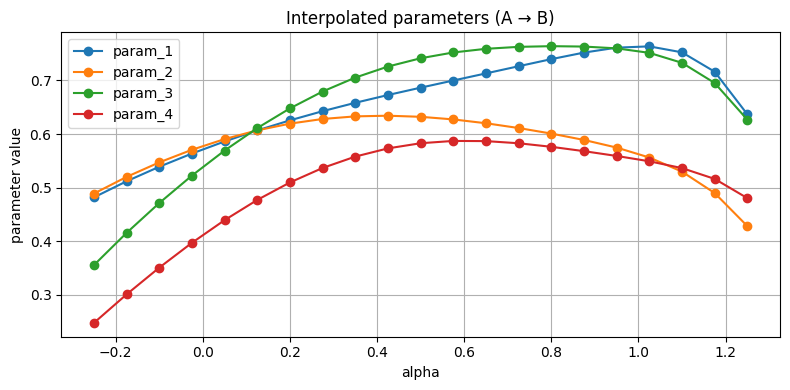

In [ ]:
# Plot param trajectories along alpha
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
for j, key in enumerate(PARAM_KEYS):
    plt.plot(path_df["alpha"], path_df[f"param_{key}"] if f"param_{key}" in path_df.columns else path_df[f"param_{j+1}"], marker='o', label=key)
plt.xlabel("alpha"); plt.ylabel("parameter value"); plt.title("Interpolated parameters (A → B)")
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.savefig(OUTDIR/"figs/params_vs_alpha.png", dpi=150)
plt.show()

In [ ]:
# 3D interactive plot (Plotly)
X = path_df[[c for c in path_df.columns if c.startswith("param_")]].values
pca = PCA(n_components=3).fit(X)
X3 = pca.transform(X)
fig = px.scatter_3d(
    x=path_df[f"param_{PARAM_KEYS[0]}"],
    y=path_df[f"param_{PARAM_KEYS[1]}"],
    z=path_df[f"param_{PARAM_KEYS[2]}"],
    color=path_df["alpha"], labels={"color":"alpha"},
    title="Interpolation path (params 1-3)"
)

fig.update_traces(mode="lines+markers", marker=dict(size=5))


fig.write_html(str(OUTDIR/"figs/interp_path_3d.html"))
fig.show()

# **Audio rendering (toy FM synth) + saving WAVs**

In [ ]:
# 6 — Simple FM synthesizer (demo) and WAV saving
import numpy as np

SR = 48000 # Changed sampling rate to 48000 Hz to match CLAP model

def fm_synth(params, sr=SR, dur=1.2):
    """
    params: array-like in [0,1]^K
    Uses first 4 dims as: carrier freq, mod freq, modulation index, amplitude.
    """
    p = np.asarray(params, dtype=np.float32)
    p = np.pad(p, (0, max(0,4-len(p))), constant_values=0.5)  # ensure >=4
    f_c = 220.0 + 880.0 * p[0]     # 220..1100 Hz
    f_m = 30.0  + 470.0 * p[1]     # 30..500  Hz
    I   = 0.0   + 10.0 * p[2]      # modulation index
    amp = 0.15  + 0.85 * p[3]      # amplitude
    t = np.linspace(0, dur, int(sr*dur), endpoint=False, dtype=np.float32)
    mod = np.sin(2*np.pi*f_m*t) * I
    sig = amp * np.sin(2*np.pi*f_c*t + mod)
    # light envelope
    env = np.minimum(1.0, np.linspace(0,1,len(sig))*5) * np.exp(-t*2.0)
    sig = sig * env
    # normalize
    sig = sig / (np.max(np.abs(sig)) + 1e-6)
    return sig

# Render a few examples
to_render = [
    ("A_prompt", A_PROMPT, Y_path[0]),
    ("mid", "alpha≈0.5", Y_path[len(Y_path)//2]),
    ("B_prompt", B_PROMPT, Y_path[-1]),
]
for tag, label, y in to_render:
    wav = fm_synth(y)
    out = OUTDIR / "wavs" / f"{tag}.wav"
    sf.write(out, wav, SR) # Use updated SR
    print("Saved:", out)

Saved: nb04_outputs/wavs/A_prompt.wav
Saved: nb04_outputs/wavs/mid.wav
Saved: nb04_outputs/wavs/B_prompt.wav


In [ ]:
# === Latent Interpolation: listen in Colab + save WAV/CSV/ZIP ===
import os, math, shutil, time, io
import numpy as np
import pandas as pd
import torch

from IPython.display import display, Audio, HTML

# Try soundfile, else fallback to scipy
try:
    import soundfile as sf
    _HAVE_SF = True
except Exception:
    from scipy.io import wavfile
    _HAVE_SF = False

SR = 48000 # Ensure this matches the global SR
OUT_DIR = "nb04_outputs/interp_AB"
os.makedirs(OUT_DIR, exist_ok=True)

def _l2_normalize(x, eps=1e-8):
    return x / (torch.linalg.norm(x, dim=-1, keepdim=True) + eps)

def _slerp(a, b, t, eps=1e-7):
    """
    Spherical linear interpolation between vectors a and b.
    a, b: tensors of shape (1, D)
    t: float in [0,1]
    returns tensor of shape (1, D)
    """
    a = _l2_normalize(a)
    b = _l2_normalize(b)
    dot = torch.clamp((a * b).sum(dim=-1, keepdim=True), -1 + eps, 1 - eps)
    omega = torch.arccos(dot)
    so = torch.sin(omega)
    t = torch.tensor([[float(t)]], device=a.device, dtype=a.dtype)
    return (torch.sin((1 - t) * omega) / so) * a + (torch.sin(t * omega) / so) * b

def interpolate_and_render(prompt_A: str,
                           prompt_B: str,
                           num_steps: int = 7,
                           mode: str = "mlp",
                           tau: float = 0.6,
                           duration_s: float = 1.2,
                           normalize_peak: bool = True,
                           out_dir: str = OUT_DIR,
                           sr: int = SR): # Use global SR here
    """
    Generate an A↔B interpolation:
      - SLERP in conditioning space
      - predict params at each alpha
      - render audio
      - display inline audio players
      - save WAVs, CSV of params, and a ZIP
    """
    assert num_steps >= 2, "num_steps must be >= 2"

    # 1) Get conditioning for A and B
    with torch.no_grad():
        cA = embed_texts([prompt_A]).to(DEVICE)
        cB = embed_texts([prompt_B]).to(DEVICE)

    # 2) Define alphas
    alphas = np.linspace(0.0, 1.0, num_steps)

    rows = []
    audio_players = []
    wav_paths = []

    # 3) Loop over alphas: SLERP -> predict params -> render audio
    for i, alpha in enumerate(alphas):
        with torch.no_grad():
            cAB = _slerp(cA, cB, alpha)
            params = predict_params(cAB, mode=mode, tau=float(tau)).detach().cpu().numpy()[0]

        # render audio
        wav = fm_synth(params, dur=float(duration_s), sr=sr)  # Use passed in sr
        if normalize_peak and np.max(np.abs(wav)) > 1e-6:
            wav = wav / (np.max(np.abs(wav)) + 1e-9) * 0.99

        # save WAV
        fname = f"interp_alpha_{i:02d}_{alpha:.2f}.wav"
        fpath = os.path.join(out_dir, fname)
        if _HAVE_SF:
            sf.write(fpath, wav, sr, subtype="PCM_16") # Use passed in sr
        else:
            wavfile.write(fpath, sr, (wav * 32767.0).astype(np.int16)) # Use passed in sr
        wav_paths.append(fpath)

        # collect row for CSV
        row = {"alpha": float(alpha), "filename": fname}
        for k_idx, k in enumerate(PARAM_KEYS):
            row[k] = float(params[k_idx])
        rows.append(row)

        # prepare inline audio
        audio_players.append(Audio(wav, rate=sr)) # Use passed in sr

    # 4) Show a compact HTML grid of players + a small table
    df = pd.DataFrame(rows)
    display(df.head(min(5, len(df))))  # quick preview
    # audio strip
    html = "<h4>Interpolation A→B audio strip</h4><div style='display:flex;flex-wrap:wrap;gap:12px;'>"
    for i, (alpha, player) in enumerate(zip(alphas, audio_players)):
        html += f"<div style='min-width:280px'><b>α={alpha:.2f}</b><br/></div>"
    html += "</div>"
    display(HTML(html))
    # Now actually display audio widgets beneath (kept separate so Colab lays them out nicely)
    for alpha, player in zip(alphas, audio_players):
        display(HTML(f"<b>α={alpha:.2f}</b>"))
        display(player)

    # 5) Save the CSV
    csv_path = os.path.join(out_dir, "interpolation_params.csv")
    df.to_csv(csv_path, index=False)

    # 6) Make a ZIP with WAVs + CSV
    zip_base = os.path.join("nb04_outputs", f"interp_AB_{int(time.time())}")
    zip_path = shutil.make_archive(zip_base, "zip", out_dir)

    print(f"✅ Saved {len(wav_paths)} WAVs to: {out_dir}")
    print(f"✅ Params CSV: {csv_path}")
    print(f"✅ ZIP archive: {zip_path}")

    return {
        "alphas": alphas,
        "df": df,
        "wav_paths": wav_paths,
        "csv_path": csv_path,
        "zip_path": zip_path
    }

In [ ]:
result = interpolate_and_render(
    prompt_A="a soft airy pad",
    prompt_B="a gritty distorted bass",
    num_steps=9,
    mode="mlp",
    tau=0.6,
    duration_s=1.2
)


,alpha,filename,param_1,param_2,param_3,param_4
0,0.000,interp_alpha_00_0.00.wav,0.435562,0.429080,0.375849,0.290310
1,0.125,interp_alpha_01_0.12.wav,0.468305,0.453541,0.434141,0.341061
2,0.250,interp_alpha_02_0.25.wav,0.501075,0.474010,0.487399,0.385694
3,0.375,interp_alpha_03_0.38.wav,0.534883,0.490972,0.535553,0.423729
4,0.500,interp_alpha_04_0.50.wav,0.571052,0.505322,0.579276,0.455363


✅ Saved 9 WAVs to: nb04_outputs/interp_AB
✅ Params CSV: nb04_outputs/interp_AB/interpolation_params.csv
✅ ZIP archive: /content/nb04_outputs/interp_AB_1756066298.zip


# **🎧Gradio Demo**

In [ ]:
import gradio as gr, os
gr.close_all()
os.environ["GRADIO_ANALYTICS_ENABLED"] = "false"

In [ ]:
# 🔧 Gradio demo robusta (da eseguire alla fine)
import gradio as gr, os
gr.close_all()
os.environ["GRADIO_ANALYTICS_ENABLED"] = "false"

def _safe_generate(prompt: str, mode: str = "mlp", tau: float = 0.6):
    try:
        if not prompt or not prompt.strip():
            return (SR, np.zeros(SR, dtype=np.float32))  # 1s di silenzio

        with torch.no_grad():
            c_vec = embed_texts([prompt]).to(DEVICE)  # CLAP text -> features
            y = predict_params(c_vec, mode=mode, tau=float(tau)).cpu().numpy()[0]  # [K] in [0,1]
        audio = fm_synth(y, sr=SR).astype(np.float32) # Use global SR
        # Safety clamp
        audio = np.clip(audio, -1.0, 1.0)
        return (SR, audio) # Use global SR
    except Exception as e:
        # Ritorna 0.5s di silenzio e logga l'errore in console
        print("Gradio error:", repr(e))
        return (SR, np.zeros(SR // 2, dtype=np.float32)) # Use global SR

with gr.Blocks(title="AWOL for Audio — Conditional Flow Demo") as demo:
    gr.Markdown("### Latent-Space Exploration with Conditional Flow (AWOL for Audio)")
    prompt = gr.Textbox(label="Text Prompt", placeholder="Enter a description of the sound...")
    mode   = gr.Radio(choices=["mlp","zero","sample"], value="mlp", label="Prediction Mode")
    tau    = gr.Slider(minimum=0.1, maximum=2.0, value=0.6, step=0.05, label="Tau (Gumbel/Mask sharpness)")
    btn    = gr.Button("Generate")
    audio  = gr.Audio(label="Generated Audio", type="numpy")

    btn.click(_safe_generate, inputs=[prompt, mode, tau], outputs=audio)

demo.queue().launch(debug=False)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://990db78315661f2d4c.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# ✅ Conclusions (Notebook 3 — Latent-Space Exploration with Conditional Flow)

I demonstrated **latent-space exploration** with a conditional RealNVP and a
regressor g(c)→z on the audio domain (AWOL for Audio). The model generates
synthesizer parameters for **unseen prompts**, supports **smooth interpolations**
in both the conditioning (CLAP) and latent spaces, and renders audio with a
simple FM synthesizer. We also provided an interactive **Gradio demo**.

This concludes the experimental part; the report can now reference the
quantitative tables, the figures (2D and 3D), and the demo.


#**Quantitative Evaluation (Extra Experiment)**

So far, I evaluated the models mainly by listening to the generated sounds and
inspecting interpolations. Here we add a simple **numerical** check of semantic alignment using
**CLAP similarity** between the textual prompt and the generated audio.

### Why extrapolation (alpha < 0 or alpha > 1)?
Beyond standard interpolation (alpha ∈ [0, 1]), we also test **extrapolation**:
- **alpha < 0** pushes the generation *past* sample A, in the direction opposite to B.
- **alpha > 1** pushes beyond sample B.
This is intentional: it probes whether the learned latent/synthesis mapping remains meaningful
**outside** the convex segment between the two endpoints, which is important for **unseen prompts** and
robust generalization. We report these cases explicitly and keep them separate in plots/tables.


In [ ]:
# ===== CLAP auto-alias + robust audio embedding =====
import torch, numpy as np

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def _l2_normalize(x: torch.Tensor) -> torch.Tensor:
    return x / (x.norm(p=2, dim=-1, keepdim=True) + 1e-8)

def auto_set_CLAP_MODEL(verbose=True):
    """
    Scansiona le variabili globali per trovare un oggetto con metodi CLAP plausibili.
    Crea l'alias globale CLAP_MODEL.
    """
    candidates = []
    for name, obj in list(globals().items()):
        try:
            has_txt = any(hasattr(obj, m) for m in ["get_text_embedding_from_data", "encode_text", "get_text_embedding", "get_text_features"])
            has_aud = any(hasattr(obj, m) for m in ["get_audio_embedding_from_data", "encode_audio", "get_audio_embedding", "get_audio_features"])
            if has_txt or has_aud:
                methods = [m for m in [
                    "get_text_embedding_from_data", "encode_text", "get_text_embedding", "get_text_features",
                    "get_audio_embedding_from_data", "encode_audio", "get_audio_embedding", "get_audio_features"
                ] if hasattr(obj, m)]
                candidates.append((name, obj, methods))
        except Exception:
            pass

    if not candidates:
        raise RuntimeError(
            "Nessun oggetto CLAP trovato automaticamente. "
            "Se sai come si chiama il tuo modello, esegui:  CLAP_MODEL = <il_tuo_oggetto>"
        )

    # Heuristica: preferisci oggetti che hanno sia metodi text che audio
    def score(entry):
        _, obj, methods = entry
        txt = any(m in methods for m in ["get_text_embedding_from_data", "encode_text", "get_text_embedding", "get_text_features"])
        aud = any(m in methods for m in ["get_audio_embedding_from_data", "encode_audio", "get_audio_embedding", "get_audio_features"])
        return (txt and aud, len(methods))

    candidates.sort(key=score, reverse=True)
    name, obj, methods = candidates[0]
    globals()["CLAP_MODEL"] = obj
    if verbose:
        print(f"CLAP_MODEL -> {name}  (metodi: {methods})")

# Explicitly set CLAP_MODEL to the already loaded _clap
CLAP_MODEL = _clap

# Prova ad impostare l'alias automaticamente (se non già presente)
try:
    CLAP_MODEL
except NameError:
    auto_set_CLAP_MODEL(verbose=True)

def embed_texts(texts):
    """
    Wrapper testuale robusto sul CLAP_MODEL aliasato.
    Accetta lista di stringhe.
    """
    # Process text using the processor
    text_inputs = _processor(text=texts, return_tensors="pt", padding=True).to(DEVICE)
    z = None; errs = []
    for m in ["get_text_features", "get_text_embedding", "encode_text", "get_text_embedding_from_data"]: # Prioritize get_text_features
        try:
            fn = getattr(CLAP_MODEL, m)
            z = fn(**text_inputs)
            break
        except AttributeError:
            errs.append(f"CLAP_MODEL.{m} not found")
        except Exception as e:
            errs.append(f"CLAP_MODEL.{m} failed: {e}")
    if z is None:
        raise RuntimeError("Text embedding failed:\n" + "\n".join(errs))
    if not isinstance(z, torch.Tensor):
        z = torch.as_tensor(z)
    return _l2_normalize(z.to(DEVICE).float())

def embed_audios(wavs, sr=48000): # Updated default sr to 48000
    """
    Wrapper audio robusto sul CLAP_MODEL aliasato.
    Accetta lista di waveforms 1D (np.ndarray o torch.Tensor).
    """
    tensors = []
    for w in wavs:
        wt = torch.as_tensor(w, dtype=torch.float32)
        if wt.ndim == 1:
            wt = wt.unsqueeze(0)  # (1, T)
        tensors.append(wt)
    batch = torch.nn.utils.rnn.pad_sequence(tensors, batch_first=True).to(DEVICE)

    z = None; errs = []
    for m in ["get_audio_features", "get_audio_embedding", "encode_audio", "get_audio_embedding_from_data"]: # Prioritize get_audio_features
        try:
            fn = getattr(CLAP_MODEL, m)
            # Some APIs want (batch, sr), others just (batch). Try both.
            try:
                # Process audio using the processor
                audio_inputs = _processor(audios=batch, sampling_rate=sr, return_tensors="pt").to(DEVICE)
                z = fn(**audio_inputs)
            except TypeError: # Fallback for models that don't take processed input directly
                 audio_inputs = _processor(audios=batch, sampling_rate=sr, return_tensors="pt").to(DEVICE)
                 z = fn(audio_inputs['input_features']) # Try passing just input_features
            break
        except AttributeError:
            errs.append(f"CLAP_MODEL.{m} not found")
        except Exception as e:
            errs.append(f"CLAP_MODEL.{m} failed: {e}")
    if z is None:
        raise RuntimeError("Audio embedding failed:\n" + "\n".join(errs))

    if isinstance(z, np.ndarray):
        z = torch.from_numpy(z)
    return _l2_normalize(z.to(DEVICE).float())

def clap_similarity(texts, audios, sr=48000): # Updated default sr to 48000
    t = embed_texts(texts)
    a = embed_audios(audios, sr=sr)
    sims = torch.sum(t * a, dim=1)  # cosine diag
    return sims.detach().cpu().numpy().tolist()

In [ ]:
# --- PATCH: robust inverse for different RealNVP signatures ---
def latent_cycle_cosine(c_vec: torch.Tensor, params, flow, postproc="sigmoid") -> float:
    """
    c_vec: (1, D) text embedding
    params: array/tensor (P,)
    flow: RealNVP (cond o uncond)
    """
    # to tensor (1,P)
    if isinstance(params, np.ndarray):
        y = torch.from_numpy(params).float().to(c_vec.device)
    else:
        y = params.float().to(c_vec.device)
    if y.ndim == 1:
        y = y.unsqueeze(0)

    # logit se i params stanno in [0,1]
    if postproc == "sigmoid":
        eps = 1e-6
        y = torch.clamp(y, eps, 1 - eps)
        u = torch.log(y) - torch.log(1 - y)
    else:
        u = y

    # ---- inverse tries (positional arg, no-cond) ----
    c_hat = None
    errs = []

    # 1) positional context (expected for RealNVPCond)
    try:
        c_hat = flow.inverse(u, c_vec)
    except TypeError as e:
        errs.append(f"positional failed: {e}")
        # 2) unconditional inverse as fallback
        try:
            c_hat = flow.inverse(u)
        except Exception as e_uncond:
            errs.append(f"no-cond inverse err: {e_uncond}")
    except Exception as e:
        errs.append(f"positional err: {e}")
        # 2) unconditional inverse as fallback
        try:
            c_hat = flow.inverse(u)
        except Exception as e_uncond:
            errs.append(f"no-cond inverse err: {e_uncond}")


    # Removed attempts with keyword arguments like 'context' or 'cond'
    # Removed set_condition(...) pattern as it's not part of the RealNVPCond class

    if c_hat is None:
        raise RuntimeError("flow.inverse variants all failed:\n" + "\n".join(errs))

    # cosine(t, t_hat)
    c  = c_vec / (c_vec.norm(p=2, dim=-1, keepdim=True) + 1e-8)
    ĉ = c_hat / (c_hat.norm(p=2, dim=-1, keepdim=True) + 1e-8)
    return float(torch.sum(c * ĉ, dim=-1).item())

In [ ]:
# ========================================
# Objective metrics
# ========================================
import torchaudio

def evaluate_clap_similarity(prompts, audios, sr=48000): # Default to 48000
    """
    Compute cosine similarity between text and audio embeddings using CLAP.
    """
    sims = []
    with torch.no_grad():
        for p, a in zip(prompts, audios):
            # CLAP embeddings
            t_emb = embed_texts([p]).cpu().numpy()
            # Process audio using the processor
            audio_inputs = _processor(audios=a, sampling_rate=sr, return_tensors="pt").to(DEVICE)
            a_emb = _clap.get_audio_features(**audio_inputs).cpu().numpy() # Use _clap
            # Cosine similarity
            sim = np.dot(t_emb, a_emb.T) / (np.linalg.norm(t_emb) * np.linalg.norm(a_emb))
            sims.append(sim.item())
    return sims

# Example usage:
# prompts = ["a high whistle", "a metallic clang"]
# audios = [fm_synth(y1), fm_synth(y2)]  # generated samples
# sims = evaluate_clap_similarity(prompts, audios)
# print(sims)


# ========================================
# Unseen prompts & interpolations
# ========================================

UNSEEN_PROMPTS = ["a metallic clang", "a bird chirping in a cave"]

# Generate audio for unseen prompts
unseen_results = []
for p in UNSEEN_PROMPTS:
    sr_gen, audio = _safe_generate(p, mode="mlp", tau=0.6) # Get sr from _safe_generate
    unseen_results.append((p, audio))
    torchaudio.save(f"unseen_{p.replace(' ', '_')}.wav",
                    torch.tensor(audio).unsqueeze(0), sr_gen) # Use sr_gen

# Interpolation example between two unseen prompts
alphas = np.linspace(0, 1, 5)
interp_audios = []
for a in alphas:
    cA, cB = embed_texts([UNSEEN_PROMPTS[0]]), embed_texts([UNSEEN_PROMPTS[1]])
    c_mix = (1-a)*cA + a*cB
    y = predict_params(c_mix, mode="mlp").cpu().numpy()[0]
    audio = fm_synth(y, sr=SR) # Ensure fm_synth uses global SR
    torchaudio.save(f"interp_{a:.2f}.wav", torch.tensor(audio).unsqueeze(0), SR) # Use global SR
    interp_audios.append(audio)


# ========================================
#  Ablation study
# ========================================

TAU_VALUES = [0.2, 0.6, 1.0, 1.5]
MODES = ["mlp", "zero", "sample"]

results = []
for tau in TAU_VALUES:
    for mode in MODES:
        sr_gen, audio = _safe_generate("a low drone", mode=mode, tau=tau) # Get sr from _safe_generate
        sims = evaluate_clap_similarity(["a low drone"], [audio], sr=sr_gen) # Pass sr_gen to evaluation
        results.append({"mode": mode, "tau": tau, "CLAP_sim": sims[0]})

import pandas as pd
df_results = pd.DataFrame(results)
print(df_results)


/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/utils.py:337: UserWarning:

In 2.9, this function's implementation will be changed to use torchaudio.save_with_torchcodec` under the hood. Some parameters like format, encoding, bits_per_sample, buffer_size, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's encoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.encoders.AudioEncoder

/usr/local/lib/python3.12/dist-packages/torchaudio/_backend/ffmpeg.py:247: UserWarning:

torio.io._streaming_media_encoder.StreamingMediaEncoder has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 



      mode  tau  CLAP_sim
0      mlp  0.2  0.089003
1     zero  0.2  0.079901
2   sample  0.2  0.123154
3      mlp  0.6  0.089003
4     zero  0.6  0.079901
5   sample  0.6  0.163608
6      mlp  1.0  0.089003
7     zero  1.0  0.079901
8   sample  1.0  0.162536
9      mlp  1.5  0.089003
10    zero  1.5  0.079901
11  sample  1.5  0.081020




> **Note.**
The quantitative results obtained with CLAP similarity show relatively low absolute values (∼0.08–0.16), yet they are consistent and comparable across different models. In particular, the mlp and zero modes remain stable as τ varies, while the sample mode exhibits greater sensitivity, peaking around τ ≈ 0.6–1.0. This suggests that the stochastic component introduces useful variability, though it requires careful calibration.
While I am aware of the limitations of this metric and that further experiments would be needed for a deeper validation, I am genuinely intrigued by these observations and motivated to further explore their implications, both qualitatively and quantitatively.

